# BoxCar Ride-Sharing Simulation

This notebook implements a discrete-event simulation of the BoxCar ride-sharing system operating in Squareshire county.

The simulation models the interactions between drivers and riders, including:
- driver arrivals and departures
- rider arrivals and patience behavior (abandonment)
- driver–rider matching
- pickup and trip completion

### Model Overview

The main events modeled in the system are:

1. Driver Arrival
2. Rider Arrival
3. Pickup Start
4. Pickup
5. Dropoff
6. Rider Abandonment
7. Driver Offline
8. Termination

The simulation continues until the termination time is reached.

### Simulation Assumptions

The distributions of the driver and rider arrivals, travel times, and locations are assumed from the project brief from BoxCar. 

## 0. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

## 1. Parameters and Functions
The constant parameters of the system include:
- Side length of Squareshire
- Travel speed 
- Base fare for a trip
- Additional cost per mile 
- Petrol cost per mile

In [ ]:
county_size = 20 # miles
taxi_speed = 20 # miles per hour
base_fare = 3.00 # pounds
per_mile_fare = 2.00 # pounds per mile
petrol_cost = 0.2 # pounds per mile

## 2. Helper Functions

The following functions support the simulation model.

These functions include:

- generating random driver and rider locations
- computing Euclidean distance between points
- converting travel distance into travel time

In [32]:
def distance(loc1, loc2):
    '''Calculate Euclidean distance between two locations (list: [x,y])'''
    return np.sqrt((loc1[0] - loc2[0])**2 + (loc1[1] - loc2[1])**2)

def generate_location():
    '''Generate Squareshire location from Uniform distribution'''
    return (random.uniform(0, county_size), random.uniform(0, county_size))

def travel_time(d_OD):
    '''Calculate the expected travel time mu_t, then generate the actual travel time 
    from the assumed distribition'''
    mu = d_OD / taxi_speed
    return random.uniform(0.8*mu, 1.2*mu) 

## 3. Updated Simulation Model

The core of the model is implemented in the function `run_simulation()`.

This function simulates the system of the ride-sharing platform for a specified number of hours. The simulation maintains an event calendar that determines the order in which events occur.

The function tracks system performance metrics including:

- number of drivers and riders
- total rides completed
- driver earnings
- rider waiting times
- abandoned rides

In [ ]:
def run_simulation(T, iter_D , iter_R, lambda1, lambda2):
    ''' Runs the rideshare Simulation with BoxCar's initial assumptions. 
            Inputs:
            - T: Termination Time (in hours)
            - iter_D: Driver ID iteration start
            - iter_R: Rider ID iteration start
            Output:
            - results: dictionary of performance metrics indexed by metric type '''

    ##################################
    # Initialize Performance Metrics #  
    ##################################    
    N_D = 0
    N_R = 0
    T_D = 0
    T_R = 0
    P = 0
    R = 0                   # total completed rides
    matched_rides = 0       # started but dropoff is after TerminationTime - do not count driver earnings
    picked_up_rides = 0     # matched and actually gets picked up before TerminationTime
    abandoned_rides = 0     # abandoned due to patience time being reached
    T_P = []
    T_All = []
    T_W = []
    driver_ride_counts = {}
    driver_idle_time = {}
    driver_last_busy_time = {}

    ###############################
    # Initialize Simulation State #  
    ###############################        
    TNOW = 0
    TerminationTime = T #hrs
    EventCalendar = []
    def schedule_event(time, event_type, data=None):
        '''Event scheduler that keeps track of times, event type, and user data (optional)'''
        EventCalendar.append((time,event_type,data))
   
    drivers =[]
    idle_drivers=[]
    riders = []
    waiting_riders=[]

    driver_id_counter = iter_D
    rider_id_counter = iter_R

    # Schedule first arrivals and termination events
    schedule_event(random.expovariate(3), 1)   # 1 = Driver Arrival
    schedule_event(random.expovariate(30), 2)  # 2 = Rider Arrival
    schedule_event(TerminationTime, 8)         # 8 = Termination

    # Matching decisions are made using this scoring rule:
    def driver_score(driver, rider, TNOW, lambda1, lambda2):
        '''calculate the score of the driver according to 
            score = distance + l1*profit_per_driver/online_time - l2*current_break_time'''
        
        d = distance(driver['location'], rider['origin'])
        
        # small constant 1e-6 prevents division by zero if driver just went online.
        time_active = TNOW - driver['online_time'] + 1e-6
        
        profit_rate = driver['earnings'] / time_active
        
        break_time = TNOW - driver_last_busy_time[driver['id']]

        return d + lambda1 * profit_rate - lambda2 * break_time
    
    #########################
    # Event Processing Loop #
    #########################
    while TNOW < TerminationTime:
        TNEXT, TypeNext, Data = min(EventCalendar, key=lambda x: x[0])
        EventCalendar.remove((TNEXT, TypeNext, Data))
        TNOW = TNEXT

        ### 1. DriverArrival ###
        if TypeNext == 1:
            driver_id_counter += 1

            # Generate driver location and offline time (initialize other attributes)
            driver = {
                "id": driver_id_counter,
                "location": generate_location(),
                'offline_time': TNOW + random.uniform(5,8),
                'idle': True,
                'active': True,
                'earnings': 0,
                'online_time': TNOW
            }
            drivers.append(driver)

            # Update performance metrics immediately
            N_D += 1
            driver['online_time'] = TNOW
            driver_ride_counts[driver['id']] = 0
            driver_idle_time[driver['id']] = 0
            driver_last_busy_time[driver['id']] = TNOW

            # Schedule offline time
            schedule_event(driver['offline_time'], event_type=7, data = driver)

            # Match driver to waiting rider
            if waiting_riders:
                # match closest waiting rider
                rider = min(
                    waiting_riders,
                    key=lambda r: driver_score(driver, r, TNOW, lambda1, lambda2)
                )
                waiting_riders.remove(rider)
                
                # update statuses
                rider['status'] = 'matched'
                driver['idle'] = False
                
                # schedule pickup start
                schedule_event(TNOW, event_type=3, data = (driver, rider)) 

                # update performance metrics
                matched_rides += 1
            else:
                idle_drivers.append(driver)
            
            # Schedule next driver arrival
            schedule_event(TNOW + random.expovariate(3), event_type=1)

        ### 2. RiderArrival ###
        elif TypeNext == 2: 
            rider_id_counter += 1

            # Generate rider location and patience time (initialize other attributes)
            rider = {
                "id": rider_id_counter,
                "origin": generate_location(),
                'destination': generate_location(),
                'patience_time': random.expovariate(5),
                'status': 'waiting'
            }
            riders.append(rider)
            
            # Match driver to idle active driver
            idle_active_drivers = [driver for driver in idle_drivers if driver['active']]

            if idle_active_drivers:
                # Use weighted matching metric
                driver = min(idle_active_drivers,
                    key=lambda d: driver_score(d, rider, TNOW, lambda1, lambda2)
                )
                # update statuses
                rider['status'] = 'matched'
                driver['idle'] = False

                # schedule PickupStart
                schedule_event(TNOW, event_type=3, data = (driver,rider))

                # update performance metrics
                matched_rides += 1
            else:
                waiting_riders.append(rider)

                #schedule patience deadline for waiting rider
                schedule_event(TNOW+rider['patience_time'], event_type=6, data = rider)
            
            # schedule next rider arrival
            schedule_event(TNOW + random.expovariate(30), event_type=2)

            # Update performance metrics
            N_R += 1
            rider['arrival_time'] = TNOW
            #T_P.append(rider['patience_time'])

        ### 3. PickupStart ###
        elif TypeNext == 3:
            driver,rider = Data

            # in very rare event that driver becomes offline at exact time it gets matched, 
            # add rider back to waiting list
            if not driver['active']:
                rider['status'] = 'waiting'
                waiting_riders.append(rider)
                continue
            
            # Calculate actual travel time 
            d_P = distance(driver['location'],rider['origin'])
            t_P = travel_time(d_P)

            # Schedule Pickup event
            schedule_event(TNOW + t_P, event_type=4, data = (driver,rider,d_P))

            # Update performance metrics
            waiting_time = TNOW - rider['arrival_time']  # time waited between rider arrival and matching
            T_W.append(waiting_time)
            T_All.append(waiting_time)
            T_P.append(rider['patience_time'])
            driver_ride_counts[driver['id']] += 1
            driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]
            driver_last_busy_time[driver['id']] = TNOW
            
        
        ### 4. Pickup ###
        elif TypeNext == 4:
            driver, rider, d_P = Data
            
            # Calculate actual travel time
            d_OD = distance(rider['origin'], rider['destination'])
            t_OD = travel_time(d_OD)

            # Schedule Dropoff
            schedule_event(TNOW + t_OD, event_type=5, data = (driver,rider,d_P,d_OD,t_OD))

            # update performance metrics
            picked_up_rides += 1

        ### 5. Dropoff ###
        elif TypeNext == 5:
            driver, rider, d_P, d_OD,t_OD = Data

            # update rider status
            rider["status"] = "dropped-off"

            # calculate driver earnings
            rider_fare = base_fare + per_mile_fare * d_OD
            driver_cost = petrol_cost*(d_P+d_OD)
            driver_profit = rider_fare - driver_cost
            driver['earnings'] += driver_profit      # changed this to make it cumulative profit
            
            # Update driver information
            driver['location'] = rider['destination']
            driver['idle'] = True

            # Check if driver is meant to be offline now
            if TNOW >= driver['offline_time']:
                driver['active'] = False
            else:
                if waiting_riders:
                    next_rider = min(
                        waiting_riders,
                        key=lambda r: driver_score(driver, r, TNOW, lambda1, lambda2)
                    )
                    waiting_riders.remove(next_rider)
                    next_rider['status'] = 'matched'
                    driver['idle'] = False
                    # schedule next pickup if driver gets matched to a new rider
                    schedule_event(TNOW, event_type=3, data = (driver, next_rider))

                    # update performance metrics
                    matched_rides += 1
                else:
                    idle_drivers.append(driver)

            # Update performance metrics
            R += 1
            T_R += t_OD  
            P += driver_profit
            driver_last_busy_time[driver['id']] = TNOW
        
        ### 6. RiderAbandonment ###
        elif TypeNext == 6:
            rider = Data

            # remove abandonded riders and update status
            if rider['status'] == 'waiting':
                waiting_riders.remove(rider)
                rider["status"] = "abandoned"
                abandoned_rides += 1

                # Update performance metrics
                T_All.append(rider['patience_time'])
                T_P.append(rider['patience_time'])
        
        ### 7. DriverOffline ###
        elif TypeNext == 7:
            driver = Data
            
            # remove offline drivers and update status
            if driver["active"] and driver["idle"]:
                driver["active"] = False
                if driver in idle_drivers:
                    idle_drivers.remove(driver)

            # Update performance metrics
            T_D += TNOW - driver['online_time']
            driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]

        ### 8. Termination ###
        else:
            # Update performance metrics
            for driver in drivers:
                if driver['active']:
                    T_D += TNOW - driver['online_time']
                    
                    if driver['idle']:
                        driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]
    
    #########################
    # Collect Final Results #
    #########################
    results = {
        "system_metrics": {
            "N_D": N_D,
            "N_R": N_R,
            "R": R,
            "matched_rides": matched_rides,
            "picked_up_rides": picked_up_rides,
            "abandoned_rides": abandoned_rides
        },
    
        "financial_metrics": {
            "P": P
        },

        "time_metrics": {
            "T_D": T_D,
            "T_R": T_R,
            "T_W": T_W,
            "T_P": T_P,
            "T_All": T_All
        },

        "driver_metrics": {
            "driver_ride_counts": driver_ride_counts,
            "driver_idle_time": driver_idle_time,
            "driver_last_busy_time": driver_last_busy_time
        },

        "entities": {
            "drivers": drivers,
            "riders": riders
        }
    }

    return results


## 4. Running the Simulation

We first run the simulation using the baseline parameter values to observe the system's behavior under the original BoxCar dispatch policy. 

In [31]:
results = run_simulation(100,0,0,0,0)

#### Summary Metrics (copy from alice)

## 5. Driver-Rider Matching Parameters

To evaluate alternative driver matching strategies, we introduce two parameters to balance driver fairness:

- $\lambda_1$ : penalty applied to drivers with higher profit rates
- $\lambda_2$ : reward applied to drivers who have experienced longer breaks

A grid search is performed across a range of parameter values to evaluate their effect on system performance.

---
A Note on $\lambda_1$:

When $\lambda_1$ is allowed to be near 0, it tends towards that value, even as the upper limit is increased. 

We raised the lower bound of $\lambda_1$ incrementally until the best value was greater than zero, thus resulting in the interval [0.75, 10]. 

In [ ]:
lambda1_values = np.linspace(0.75, 10, 25)   
lambda2_values = np.linspace(0, 10, 25) 

TerminationTime = 100
gridsearch_results = []
for l1 in lambda1_values:
    for l2 in lambda2_values:

        sim = run_simulation(T=TerminationTime, iter_D=0, iter_R=0, lambda1=l1, lambda2=l2)

        gridsearch_results.append({
            "lambda1": l1,
            "lambda2": l2,
            "avg_wait": np.mean(sim["time_metrics"]["T_W"]),
            "abandon_rate": sim["system_metrics"]["abandoned_rides"] / sim["system_metrics"]["N_R"],
            "total_profit": sim["financial_metrics"]["P"],
            "avg_earnings_ph": sim["financial_metrics"]["P"] / sim["time_metrics"]["T_D"],
            "average_break": np.mean([TerminationTime - sim['driver_metrics']['driver_last_busy_time'][d['id']] for d in sim['entities']['drivers'] if d['active']])
        })

### Grid Search Results
The following visualization shows how average earnings per hour varies as a function of $\lambda_1$ and $\lambda_2$. 

lambda1                8.458333
lambda2                2.916667
avg_wait               0.000017
abandon_rate           0.002030
total_profit       58391.312132
avg_earnings_ph       39.064592
average_break          1.758369
Name: 507, dtype: float64


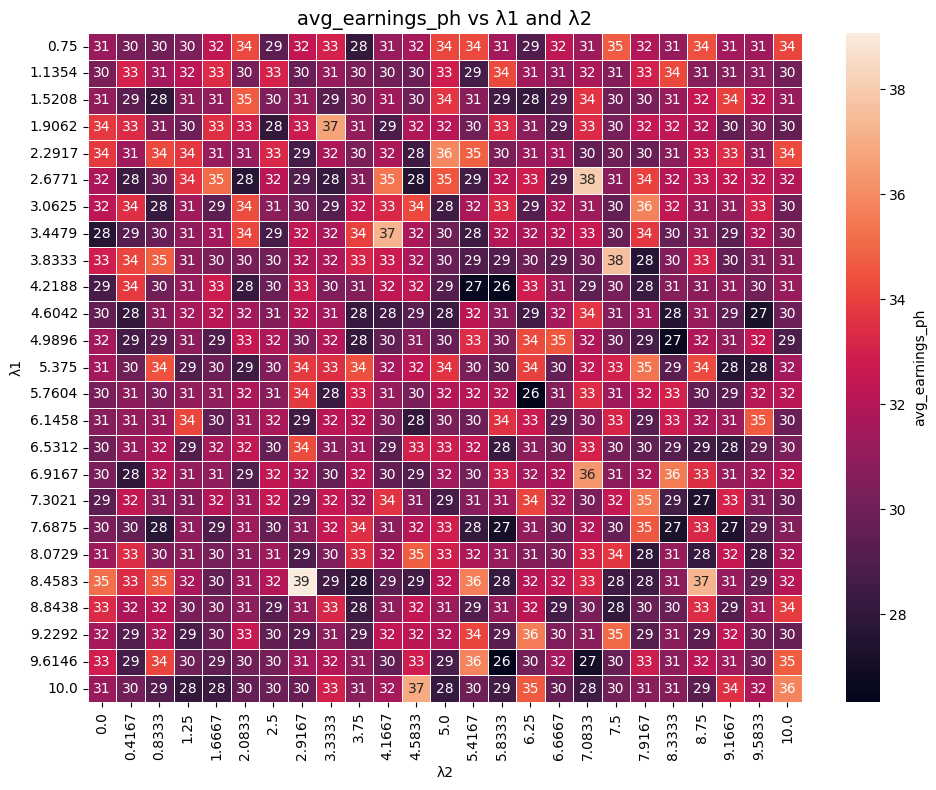

In [ ]:
df = pd.DataFrame(gridsearch_results)

best = df.loc[df["avg_earnings_ph"].idxmax()]
print(best)

import matplotlib.pyplot as plt
import seaborn as sns

# Round lambda values for cleaner axes
df["lambda1"] = df["lambda1"].round(4)
df["lambda2"] = df["lambda2"].round(4)

# Create pivot table
pivot = df.pivot(index="lambda1", columns="lambda2", values="avg_earnings_ph")

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="rocket",
    annot=True,
    #fmt=".0f",           # remove scientific notation
    linewidths=0.5,
    cbar_kws={"label": "avg_earnings_ph"}
)

plt.title("avg_earnings_ph vs λ1 and λ2", fontsize=14)
plt.xlabel("λ2")
plt.ylabel("λ1")

plt.tight_layout()
plt.show()

## 6. Implement Driver Fairness Parameters

Next, we run the simulation using the fairness-based matching parameters derived above. 

In [ ]:
## update based on what we actually need to save 
TerminationTime = 100
num_sims = 10

results = []

next_driver_id = 0
next_rider_id = 0

for i in range(num_sims):

    sim_result = run_simulation(
        TerminationTime,
        iter_D=next_driver_id,
        iter_R=next_rider_id,
        lambda1= best['lambda1'],
        lambda2= best['lambda2']
    )

    results.append(sim_result)

    # Update counters for next simulation
    next_driver_id += sim_result["system_metrics"]["N_D"]
    next_rider_id += sim_result["system_metrics"]["N_R"]


## 7. Analysis of New Matching Implementation 

do metric stuff again but with lambdas this time